# Finite Difference Method — 2D complex-valued Helmholtz (Dirichlet)

Finite-difference counterpart to the **2D complex-valued LinPDE-GP** experiment
(`inHomo_complexHelmholtz_dirichlet_2d`). The *evaluation setup is identical*: same
domain, same complex wavenumber $\kappa^2$, same constant complex source, same
homogeneous Dirichlet data, the **same** $31\times31$ evaluation grid, the **same**
sine-series analytical reference (`analytical_constant_source`), and the **same**
per-component metric blocks (Real / Imaginary / Complex $|u|$).

We solve

$$\Delta u(\mathbf{x}) + \kappa^2 u(\mathbf{x}) = f(\mathbf{x}),\qquad
u|_{\partial\Omega}=0,\qquad \Omega=[-1,1]^2,$$

with $\kappa^2 = \rho\,\omega^2/(G'+\mathrm{i}G'')$ complex whenever $G''\neq 0$.
Splitting $\kappa^2=\alpha+\mathrm{i}\beta$ is not needed here: the linear system is
assembled and solved directly over $\mathbb{C}$ (complex dtype), which is the natural
FDM analogue of the `real2` block operator used by LinPDE-GP.

In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib import patches
from typing import Dict, List, Tuple, Optional, Callable
from scipy.sparse import lil_matrix, csr_matrix
from scipy.sparse.linalg import spsolve
from scipy.interpolate import RectBivariateSpline

In [2]:
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'Helvetica', 'DejaVu Sans'],
    'font.size': 10,
    'axes.labelsize': 11,
    'axes.titlesize': 12,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
    'axes.linewidth': 0.8,
    'grid.linewidth': 0.5,
    'lines.linewidth': 1.5,
    'patch.linewidth': 0.5,
    'xtick.major.width': 0.8,
    'ytick.major.width': 0.8,
    'xtick.minor.width': 0.5,
    'ytick.minor.width': 0.5,
})
plt.rcParams['text.usetex'] = False

cmap_mean = 'plasma'
cmap_uncertainty = 'viridis'
cmap_diverging = 'RdBu_r'

## Problem parameters (identical to the LinPDE-GP 2D complex case)

`rho=1.0, omega=1.0, G_real=1.0, G_imag=0.5` give the complex wavenumber
$\kappa^2 = \rho\omega^2/(G'+\mathrm{i}G'') = 0.8 - 0.4\mathrm{i}$. The source is the
constant $f=2.0+0\mathrm{i}$ and the boundary data is homogeneous, $u|_{\partial\Omega}=0$,
exactly as in `bvp = HelmholtzEquationDirichletProblem(...)` of the GP notebook.

In [3]:
# Physical parameters (match LinPDE-GP: rho, omega, G_real=G', G_imag=G'')
rho, omega, G_real, G_imag = 1.0, 1.0, 1.0, 0.5

# Complex wavenumber squared:  kappa^2 = rho * omega^2 / (G' + i G'')
k_squared = rho * omega**2 / (G_real + 1j * G_imag)

# Constant complex source f(x) = 2 + 0i  (LinPDE-GP: rhs = Constant(to_real2(2+0j)))
f_val = 2.0 + 0.0j

# Domain and homogeneous Dirichlet boundary value u|_dOmega = 0
domain = ((-1.0, 1.0), (-1.0, 1.0))
bc_value = 0.0 + 0.0j

print(f"kappa^2 = {k_squared}")
print(f"f       = {f_val}")
print(f"domain  = {domain},   u|_dOmega = {bc_value}")

kappa^2 = (0.8-0.4j)
f       = (2+0j)
domain  = ((-1.0, 1.0), (-1.0, 1.0)),   u|_dOmega = 0j


## Finite-difference solver

Standard 5-point stencil for the isotropic Laplacian on a (possibly anisotropic) grid,

$$\frac{u_{i-1,j}-2u_{i,j}+u_{i+1,j}}{\Delta x^2}
 +\frac{u_{i,j-1}-2u_{i,j}+u_{i,j+1}}{\Delta y^2}
 +\kappa^2 u_{i,j}=f_{i,j},$$

assembled into a **complex** sparse system $A\mathbf{u}=\mathbf{b}$ and solved with
`spsolve`. Boundary nodes enforce the Dirichlet condition $u=g$ directly. This mirrors
the structure of the 2D *real* FDM reference notebook, generalised to complex dtype.

In [4]:
class HelmholtzFDMSolver2DComplex:
    r"""Finite-difference solver for the 2D complex Helmholtz equation

        (Delta + kappa^2) u(x, y) = f(x, y)    on [a,b] x [c,d]

    with Dirichlet boundary conditions u = g on the boundary. The system is
    assembled and solved over C (complex dtype), so a complex kappa^2 and/or a
    complex source f are handled natively -- the FDM analogue of the LinPDE-GP
    real2 block operator.
    """

    def __init__(
        self,
        domain: Tuple[Tuple[float, float], Tuple[float, float]] = ((-1.0, 1.0), (-1.0, 1.0)),
        n_points: Tuple[int, int] = (161, 161),
        k_squared: complex = 1.0 + 0.0j,
        source_func: Optional[Callable[[np.ndarray, np.ndarray], np.ndarray]] = None,
        boundary_func: Optional[Callable[[np.ndarray, np.ndarray], np.ndarray]] = None,
    ):
        self.domain = domain
        self.n_points = n_points
        self.nx, self.ny = n_points
        self.n_total = self.nx * self.ny
        self.k_squared = complex(k_squared)
        # Constant unit source / homogeneous Dirichlet by default
        self.source_func = source_func if source_func is not None else (lambda X, Y: np.ones_like(X, dtype=complex))
        self.boundary_func = boundary_func if boundary_func is not None else (lambda X, Y: np.zeros_like(X, dtype=complex))
        self._setup_grid()
        self.u_solution: Optional[np.ndarray] = None

    def _setup_grid(self) -> None:
        (x_min, x_max), (y_min, y_max) = self.domain
        self.x = np.linspace(x_min, x_max, self.nx)
        self.y = np.linspace(y_min, y_max, self.ny)
        self.X, self.Y = np.meshgrid(self.x, self.y, indexing="ij")
        self.dx = (x_max - x_min) / (self.nx - 1)
        self.dy = (y_max - y_min) / (self.ny - 1)

    def _get_index(self, i: int, j: int) -> int:
        return i * self.ny + j

    def _is_boundary(self, i: int, j: int) -> bool:
        return i == 0 or i == self.nx - 1 or j == 0 or j == self.ny - 1

    def build_system(self) -> Tuple[csr_matrix, np.ndarray]:
        n = self.n_total
        dx2, dy2 = self.dx ** 2, self.dy ** 2
        f_grid = self.source_func(self.X, self.Y)
        g_grid = self.boundary_func(self.X, self.Y)

        A = lil_matrix((n, n), dtype=complex)
        b = np.zeros(n, dtype=complex)
        center = -2.0 * (1.0 / dx2 + 1.0 / dy2) + self.k_squared

        for i in range(self.nx):
            for j in range(self.ny):
                idx = self._get_index(i, j)
                if self._is_boundary(i, j):
                    A[idx, idx] = 1.0
                    b[idx] = g_grid[i, j]
                else:
                    A[idx, idx] = center
                    A[idx, self._get_index(i - 1, j)] = 1.0 / dx2
                    A[idx, self._get_index(i + 1, j)] = 1.0 / dx2
                    A[idx, self._get_index(i, j - 1)] = 1.0 / dy2
                    A[idx, self._get_index(i, j + 1)] = 1.0 / dy2
                    b[idx] = f_grid[i, j]
        return A.tocsr(), b

    def solve(self) -> np.ndarray:
        A, b = self.build_system()
        print(f"Solving complex linear system of size {self.n_total} x {self.n_total} ...")
        u_flat = spsolve(A, b)
        self.u_solution = u_flat.reshape((self.nx, self.ny))
        return self.u_solution

    def interpolate(self, X_test: np.ndarray, Y_test: np.ndarray) -> np.ndarray:
        """Bicubic interpolation of the (complex) FDM solution onto arbitrary points."""
        if self.u_solution is None:
            raise ValueError("Call solve() first.")
        ir = RectBivariateSpline(self.x, self.y, self.u_solution.real)
        ii = RectBivariateSpline(self.x, self.y, self.u_solution.imag)
        return ir.ev(X_test, Y_test) + 1j * ii.ev(X_test, Y_test)

### Solve

We solve on a fine grid for an accurate FDM reference and then interpolate onto the
shared evaluation grid below — the same pattern as the 1D complex FDM notebook (solve
densely, then evaluate on the comparison grid).

In [5]:
solver = HelmholtzFDMSolver2DComplex(
    domain=domain,
    n_points=(161, 161),
    k_squared=k_squared,
    source_func=lambda X, Y: np.full_like(X, f_val, dtype=complex),   # constant f = 2 + 0i
    boundary_func=lambda X, Y: np.full_like(X, bc_value, dtype=complex),  # u = 0 on boundary
)
u_fdm = solver.solve()
print(f"Re(u) range: [{u_fdm.real.min():.4f}, {u_fdm.real.max():.4f}]")
print(f"Im(u) range: [{u_fdm.imag.min():.4e}, {u_fdm.imag.max():.4e}]")

Solving complex linear system of size 25921 x 25921 ...
Re(u) range: [-0.7066, 0.0000]
Im(u) range: [0.0000e+00, 7.3806e-02]


## Analytical reference

Identical `analytical_constant_source` sine-series used by the LinPDE-GP 2D complex
notebook (constant source $f_0=2$ on $[-1,1]^2$, homogeneous Dirichlet, odd modes,
$M=N=101$). The complex $\kappa^2$ enters through $(-\lambda_{mn}+\kappa^2)^{-1}$.

In [6]:
def analytical_constant_source(X, Y, k_squared=1.0, f0=2.0, M=101, N=101):
    """Sine-series solution of (Delta + kappa^2) u = f0 on [-1,1]^2, u=0 on boundary.

    Identical to the LinPDE-GP 2D complex notebook. Works for complex k_squared / f0.
    """
    xi = (X + 1.0) / 2.0
    eta = (Y + 1.0) / 2.0
    dtype = complex if (np.iscomplexobj(k_squared) or np.iscomplexobj(f0)) else float
    u = np.zeros_like(X, dtype=dtype)
    for m in range(1, M, 2):
        for n in range(1, N, 2):
            lam = (np.pi * m / 2) ** 2 + (np.pi * n / 2) ** 2
            denom = -lam + k_squared
            coeff = f0 * 16.0 / (np.pi ** 2 * m * n * denom)
            u += coeff * np.sin(np.pi * m * xi) * np.sin(np.pi * n * eta)
    return u

## Evaluation against the analytical complex solution

Identical to the LinPDE-GP cell: a $31\times31$ grid on $[-1,1]^2$ (`indexing="ij"`),
the same `_metrics` (relative L2, RMSE, MAE, max error, MSE), and the same three blocks
— Real part, Imaginary part, Complex $|u|$. The only difference is that `pred` comes
from the FDM solution (interpolated to the grid) instead of the GP posterior mean.

In [7]:
nx, ny = 31, 31
x = np.linspace(-1, 1, nx)
y = np.linspace(-1, 1, ny)
X, Y = np.meshgrid(x, y, indexing="ij")

# FDM prediction on the shared evaluation grid
pred_complex = solver.interpolate(X, Y)
pred_re = pred_complex.real
pred_im = pred_complex.imag

# Analytical reference (same routine, same kappa^2, same f0)
u_true = analytical_constant_source(X, Y, k_squared=k_squared, f0=2.0, M=101, N=101)
true_re, true_im = np.real(u_true), np.imag(u_true)


def _metrics(pred, true):
    pred = np.asarray(pred).ravel(); true = np.asarray(true).ravel()
    err = np.abs(pred - true)
    denom = np.linalg.norm(true)
    return {
        "mse": float(np.mean(err ** 2)),
        "rmse": float(np.sqrt(np.mean(err ** 2))),
        "mae": float(np.mean(err)),
        "max_error": float(np.max(err)),
        "relative_l2": float(np.linalg.norm(err) / denom) if denom > 0 else np.inf,
    }


m_re = _metrics(pred_re, true_re)
m_im = _metrics(pred_im, true_im)
m_cplx = _metrics(pred_complex, u_true)


def _print_block(title, m):
    print(f"\n  --- {title} ---")
    print(f"    Relative L2 Error:   {m['relative_l2']:12.6e}")
    print(f"    RMSE:                {m['rmse']:12.6e}")
    print(f"    MAE:                 {m['mae']:12.6e}")
    print(f"    Maximum Error:       {m['max_error']:12.6e}")
    print(f"    MSE:                 {m['mse']:12.6e}")


print("=" * 60)
print("EVALUATION METRICS - Complex Helmholtz 2D (FDM)".center(60))
print(f"  Grid: {nx}x{ny}   kappa^2 = {k_squared:.4f}")
print("=" * 60)
_print_block("Real Part", m_re)
_print_block("Imaginary Part", m_im)
_print_block("Complex |u|", m_cplx)
print("\n" + "=" * 60)

      EVALUATION METRICS - Complex Helmholtz 2D (FDM)       
  Grid: 31x31   kappa^2 = 0.8000-0.4000j

  --- Real Part ---
    Relative L2 Error:   2.779842e-05
    RMSE:                1.048787e-05
    MAE:                 9.135200e-06
    Maximum Error:       1.857809e-05
    MSE:                 1.099953e-10

  --- Imaginary Part ---
    Relative L2 Error:   1.218234e-05
    RMSE:                4.430577e-07
    MAE:                 3.867255e-07
    Maximum Error:       6.202268e-07
    MSE:                 1.963001e-13

  --- Complex |u| ---
    Relative L2 Error:   2.769483e-05
    RMSE:                1.049722e-05
    MAE:                 9.144108e-06
    Maximum Error:       1.858812e-05
    MSE:                 1.101916e-10



## Visualization

Same visual language as the LinPDE-GP figure: real part (top) and imaginary part
(bottom); FDM solution (`plasma`), analytical solution (`plasma`), and signed residual
(`RdBu_r` centred at zero).

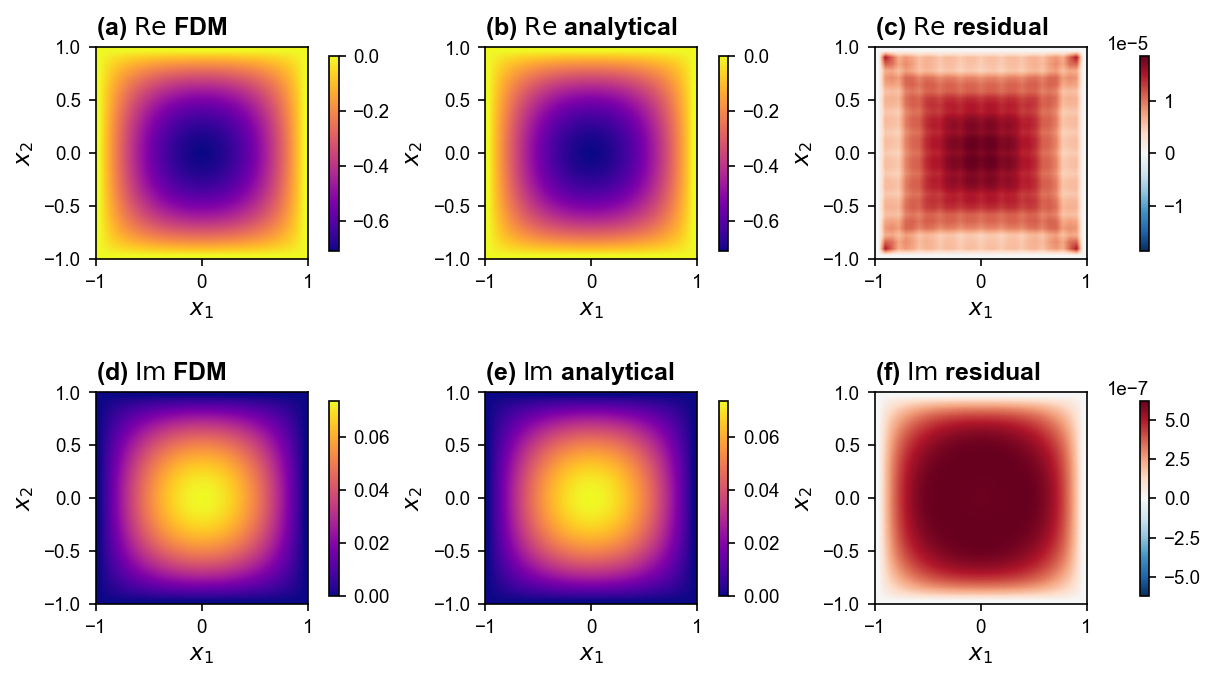

In [8]:
def plot_fdm_vs_analytical(X, Y, pred_complex, u_true,
                           extent=(-1, 1, -1, 1), figsize=(8, 4.6)):
    parts_pred = [pred_complex.real, pred_complex.imag]
    parts_true = [u_true.real, u_true.imag]
    part_tags = [r'$\mathrm{Re}$', r'$\mathrm{Im}$']
    panel = [['a', 'b', 'c'], ['d', 'e', 'f']]

    fig, axes = plt.subplots(2, 3, figsize=figsize, constrained_layout=True)
    for r in range(2):
        p, t = parts_pred[r], parts_true[r]
        res = p - t

        im0 = axes[r, 0].imshow(p.T, cmap=cmap_mean, extent=extent, origin='lower',
                                aspect='equal', interpolation='bilinear')
        axes[r, 0].set_title(f"({panel[r][0]}) {part_tags[r]} FDM", loc='left', fontweight='bold')
        fig.colorbar(im0, ax=axes[r, 0], fraction=0.046, pad=0.04)

        im1 = axes[r, 1].imshow(t.T, cmap=cmap_mean, extent=extent, origin='lower',
                                aspect='equal', interpolation='bilinear')
        axes[r, 1].set_title(f"({panel[r][1]}) {part_tags[r]} analytical", loc='left', fontweight='bold')
        fig.colorbar(im1, ax=axes[r, 1], fraction=0.046, pad=0.04)

        vmax = np.max(np.abs(res)) if np.max(np.abs(res)) > 0 else 1.0
        im2 = axes[r, 2].imshow(res.T, cmap=cmap_diverging, extent=extent, origin='lower',
                                aspect='equal', interpolation='bilinear', vmin=-vmax, vmax=vmax)
        axes[r, 2].set_title(f"({panel[r][2]}) {part_tags[r]} residual", loc='left', fontweight='bold')
        fig.colorbar(im2, ax=axes[r, 2], fraction=0.046, pad=0.04)

    for ax in axes.ravel():
        ax.set_xlabel(r'$x_1$'); ax.set_ylabel(r'$x_2$')
    return fig


fig = plot_fdm_vs_analytical(X, Y, pred_complex, u_true)
fig.savefig('./fdm_helmholtz2d_complex_residual.pdf', bbox_inches='tight')
plt.show()

## Convergence check (optional)

Grid-refinement study confirming the expected second-order $O(h^2)$ accuracy of the
5-point stencil against the same analytical solution.

In [9]:
refine = [(21, 21), (41, 41), (61, 61), (81, 81), (121, 121)]
print(f"{'grid':>10} {'h':>10} {'rel L2 (|u|)':>16} {'max err':>14}")
print("-" * 54)
hs, errs = [], []
for npg in refine:
    s = HelmholtzFDMSolver2DComplex(
        domain=domain, n_points=npg, k_squared=k_squared,
        source_func=lambda Xg, Yg: np.full_like(Xg, f_val, dtype=complex),
        boundary_func=lambda Xg, Yg: np.full_like(Xg, bc_value, dtype=complex),
    )
    u = s.solve()
    Xg, Yg = s.X, s.Y
    t = analytical_constant_source(Xg, Yg, k_squared=k_squared, f0=2.0, M=101, N=101)
    e = np.abs(u - t)
    rel = np.linalg.norm(e) / np.linalg.norm(t)
    hs.append(s.dx); errs.append(rel)
    print(f"{npg[0]:>4} x {npg[1]:<3} {s.dx:>10.4f} {rel:>16.6e} {e.max():>14.6e}")

rate = np.polyfit(np.log(hs), np.log(errs), 1)[0]
print(f"\nEstimated convergence rate: {rate:.2f}  (theoretical: 2.00)")

      grid          h     rel L2 (|u|)        max err
------------------------------------------------------
Solving complex linear system of size 441 x 441 ...
  21 x 21      0.1000     1.726200e-03   1.161144e-03
Solving complex linear system of size 1681 x 1681 ...
  41 x 41      0.0500     4.331899e-04   2.901728e-04
Solving complex linear system of size 3721 x 3721 ...
  61 x 61      0.0333     1.929372e-04   1.289941e-04
Solving complex linear system of size 6561 x 6561 ...
  81 x 81      0.0250     1.087053e-04   7.349184e-05
Solving complex linear system of size 14641 x 14641 ...
 121 x 121     0.0167     4.839548e-05   3.325658e-05

Estimated convergence rate: 1.99  (theoretical: 2.00)
